In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [2]:
# 1. Modelini Yükle (Dosya adını yüklediğin modele göre değiştir)
# Örneğin V3'ü yüklediysen buraya onun adını yaz.
MODEL_YOLU = 'MobileNet_V1_best_model.keras'
model = tf.keras.models.load_model(MODEL_YOLU)

In [3]:
# 2. Sınıf İsimleri (Alfabetik Sıraya Göre Kesin Liste)
sinif_isimleri = [
    'Atopik Dermatit (Egzama Türü)',
    'Bazal Hücreli Karkinom (BCC - Cilt Kanseri)',
    'İyi Huylu Keratoz (BKL)',
    'Egzama',
    'Melanostik Nevüs (Ben)',
    'Melanom (Tehlikeli Cilt Kanseri)',
    'Sedef ve Liken Hastalıkları',
    'Seboreik Keratoz (İyi Huylu Tümör)',
    'Mantar Enfeksiyonu (Tinea vb.)',
    'Siğil ve Viral Enfeksiyonlar'
]

In [4]:
# 3. Test Edilecek Resmi Hazırla
RESIM_YOLU = 'test_resmi.jpg'

img = image.load_img(RESIM_YOLU, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Modeller tek resim değil, "batch" bekler
img_array = img_array / 255.0 # Piksel değerlerini normalize et (0-1 arası)

In [5]:
# 4. Yapay Zeka Tahmin Yapıyor!
tahminler = model.predict(img_array)
en_olasi_indeks = np.argmax(tahminler[0])
teshis = sinif_isimleri[en_olasi_indeks]
guven_orani = tahminler[0][en_olasi_indeks] * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step


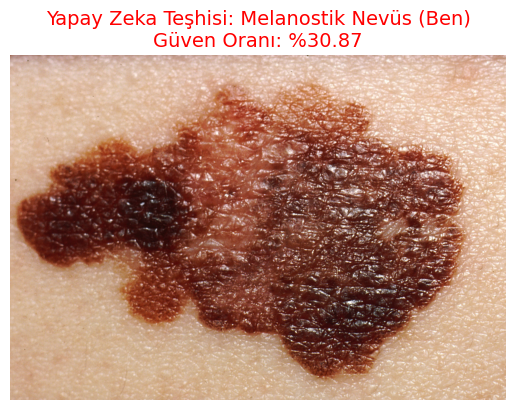

Biyoinformatik Projesi Teşhis Sonucu:
Hastalık: Melanostik Nevüs (Ben)
Yapay Zekanın Emin Olma Oranı: %30.87


In [6]:
# 5. Sonucu Ekrana Yazdır ve Resmi Göster
plt.imshow(image.load_img(RESIM_YOLU))
plt.axis('off')
plt.title(f"Yapay Zeka Teşhisi: {teshis}\nGüven Oranı: %{guven_orani:.2f}", fontsize=14, color='red')
plt.show()

print("="*40)
print(f"Biyoinformatik Projesi Teşhis Sonucu:")
print(f"Hastalık: {teshis}")
print(f"Yapay Zekanın Emin Olma Oranı: %{guven_orani:.2f}")
print("="*40)